# Task 2: Baseline Predictive Model on the Superstore Sales Dataset

**Objective:** Build a baseline supervised-learning model on the same sales dataset used in Task 1,
following standard practice: define the problem, split the data correctly, preprocess the features,
train a baseline model, evaluate it with appropriate metrics, and explain its limitations.

**Problem framing:** Task 1 found that **50.8% of all order lines lose money**. So the useful
question for the business is not "how much will this order sell for" but:

> **Will this order line be profitable or not?**

That makes this a **binary classification** problem with the target `Profitable` = 1 when
`Profit > 0`, else 0.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Clean the Data

The same cleaning steps from Task 1 are repeated here so this notebook runs on its own:
parse the dates, build the `Shipping Delay` feature, and fill the 63 missing
`Product Base Margin` values with the category median.

In [2]:
df = pd.read_csv("data/sales_data.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days

df["Product Base Margin"] = df.groupby("Product Category")["Product Base Margin"].transform(
    lambda s: s.fillna(s.median())
)

print("Shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())
df.head(3)

Shape: (8399, 22)
Missing values remaining: 0


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date,Shipping Delay
0,1,3,2010-10-13,Low,6,261.54,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20,7
1,49,293,2012-10-01,High,49,10123.02,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02,1
2,50,293,2012-10-01,High,27,244.57,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03,2


## 3. Create the Target Variable

In [3]:
df["Profitable"] = (df["Profit"] > 0).astype(int)

counts = df["Profitable"].value_counts().sort_index()
print(counts)
print()
print("Class balance:")
print((df["Profitable"].value_counts(normalize=True) * 100).round(2))

Profitable
0    4264
1    4135
Name: count, dtype: int64

Class balance:
Profitable
0    50.77
1    49.23
Name: proportion, dtype: float64


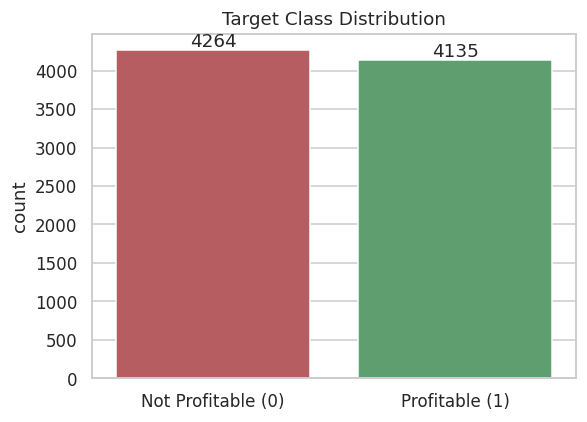

In [4]:
plt.figure(figsize=(5.5, 4))
ax = sns.countplot(x=df["Profitable"], hue=df["Profitable"], palette=["#C44E52", "#55A868"],
                   legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Profitable (0)", "Profitable (1)"])
ax.set_title("Target Class Distribution")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig("screenshots/01_target_distribution.png", bbox_inches="tight")
plt.show()

### Observation
The two classes are **almost perfectly balanced** (roughly 49% profitable, 51% not). That is
convenient: accuracy is a fair metric here, and no resampling or class weighting is needed. It also
means a "always guess the majority class" baseline would only score about **50.8%**, so the model
has to genuinely beat a coin flip to be worth anything.

## 4. Select Features

`Profit` is dropped because the target is derived from it, keeping it would leak the answer
straight into the model. ID columns and free-text names are dropped because they carry no
generalizable signal. Dates are dropped since `Shipping Delay` already captures the useful part.

In [5]:
numeric_features = ["Order Quantity", "Sales", "Discount", "Unit Price",
                    "Shipping Cost", "Product Base Margin", "Shipping Delay"]

categorical_features = ["Order Priority", "Ship Mode", "Region", "Customer Segment",
                        "Product Category", "Product Sub-Category", "Product Container"]

X = df[numeric_features + categorical_features]
y = df["Profitable"]

print("Feature matrix shape:", X.shape)
print("Numeric features    :", len(numeric_features))
print("Categorical features:", len(categorical_features))
print()
print("Dropped on purpose: Profit (target leak), Row ID, Order ID, Customer Name,")
print("Product Name, Province, Order Date, Ship Date")
X.head(3)

Feature matrix shape: (8399, 14)
Numeric features    : 7
Categorical features: 7

Dropped on purpose: Profit (target leak), Row ID, Order ID, Customer Name,
Product Name, Province, Order Date, Ship Date


,Order Quantity,Sales,Discount,Unit Price,Shipping Cost,Product Base Margin,Shipping Delay,Order Priority,Ship Mode,Region,Customer Segment,Product Category,Product Sub-Category,Product Container
0,6,261.54,0.04,38.94,35.00,0.80,7,Low,Regular Air,Nunavut,Small Business,Office Supplies,Storage & Organization,Large Box
1,49,10123.02,0.07,208.16,68.02,0.58,1,High,Delivery Truck,Nunavut,Consumer,Office Supplies,Appliances,Jumbo Drum
2,27,244.57,0.01,8.69,2.99,0.39,2,High,Regular Air,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,Small Box


## 5. Train / Test Split

An 80/20 split with `stratify=y` so both sets keep the same class balance, and a fixed
`random_state` so the result is reproducible.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Test set    :", X_test.shape[0], "rows")
print()
print("Train class balance:", (y_train.value_counts(normalize=True) * 100).round(2).to_dict())
print("Test class balance :", (y_test.value_counts(normalize=True) * 100).round(2).to_dict())

Training set: 6719 rows
Test set    : 1680 rows

Train class balance: {0: 50.77, 1: 49.23}
Test class balance : {0: 50.77, 1: 49.23}


## 6. Preprocessing Pipeline

Numeric columns are scaled with `StandardScaler` (logistic regression needs features on a similar
scale). Categorical columns are one-hot encoded.

Both steps live inside a `Pipeline`, which matters: the scaler and encoder are **fitted on the
training data only** and then applied to the test data. Doing it manually before the split would
leak test information into training.

In [7]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Peek at how many columns come out after encoding
preprocessor.fit(X_train)
n_out = preprocessor.transform(X_train).shape[1]
print("Columns before encoding:", X_train.shape[1])
print("Columns after encoding :", n_out)

Columns before encoding: 14
Columns after encoding : 54


## 7. Train the Baseline Model: Logistic Regression

In [8]:
logreg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

logreg.fit(X_train, y_train)
print("Baseline model trained.")

Baseline model trained.


## 8. Make Predictions and Evaluate

In [9]:
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

for k, v in results.items():
    print(f"{k:<10}: {v:.4f}")

Accuracy  : 0.7929
Precision : 0.8028
Recall    : 0.7678
F1 Score  : 0.7849
ROC-AUC   : 0.8657


In [10]:
print(classification_report(y_test, y_pred,
                            target_names=["Not Profitable", "Profitable"]))

                precision    recall  f1-score   support

Not Profitable       0.78      0.82      0.80       853
    Profitable       0.80      0.77      0.78       827

      accuracy                           0.79      1680
     macro avg       0.79      0.79      0.79      1680
  weighted avg       0.79      0.79      0.79      1680



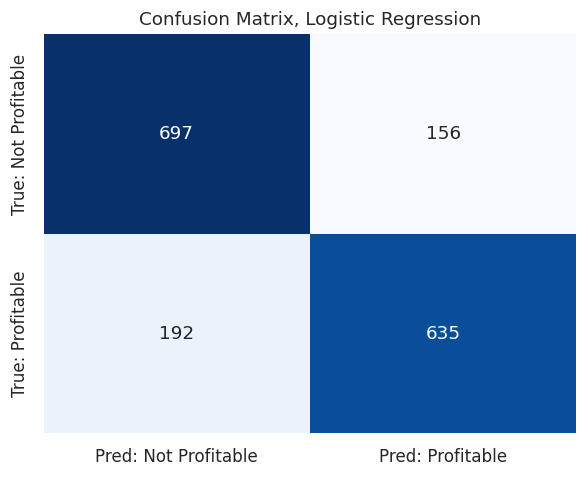

True Negatives : 697  (correctly flagged as loss-making)
False Positives: 156  (predicted profitable, actually a loss)
False Negatives: 192  (predicted a loss, actually profitable)
True Positives : 635  (correctly flagged as profitable)


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred: Not Profitable", "Pred: Profitable"],
            yticklabels=["True: Not Profitable", "True: Profitable"])
plt.title("Confusion Matrix, Logistic Regression")
plt.tight_layout()
plt.savefig("screenshots/02_confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  (correctly flagged as loss-making)")
print(f"False Positives: {fp}  (predicted profitable, actually a loss)")
print(f"False Negatives: {fn}  (predicted a loss, actually profitable)")
print(f"True Positives : {tp}  (correctly flagged as profitable)")

### What do these metrics mean?
- **Accuracy**: the share of all test orders the model classified correctly.
- **Precision**: of the orders the model called profitable, how many really were. Low precision
  means the business would approve deals that end up losing money.
- **Recall**: of the orders that really were profitable, how many the model caught. Low recall
  means turning away good business.
- **F1 Score**: the balance between precision and recall in one number.
- **ROC-AUC**: how well the model separates the two classes across every possible threshold.
  0.5 is random guessing, 1.0 is perfect.

## 9. ROC Curve

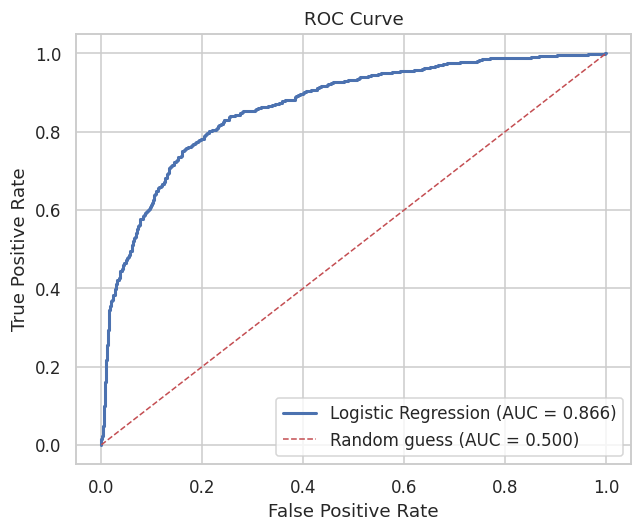

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", lw=2,
         label=f"Logistic Regression (AUC = {results['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "r--", lw=1, label="Random guess (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("screenshots/03_roc_curve.png", bbox_inches="tight")
plt.show()

## 10. Comparison Model: Decision Tree

A single baseline is hard to judge on its own, so a shallow Decision Tree is trained on the exact
same pipeline and split. Depth is capped at 5 to keep it simple and stop it memorizing the training
data.

In [13]:
tree = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
])

tree.fit(X_train, y_train)

y_pred_t = tree.predict(X_test)
y_proba_t = tree.predict_proba(X_test)[:, 1]

tree_results = {
    "Accuracy": accuracy_score(y_test, y_pred_t),
    "Precision": precision_score(y_test, y_pred_t),
    "Recall": recall_score(y_test, y_pred_t),
    "F1 Score": f1_score(y_test, y_pred_t),
    "ROC-AUC": roc_auc_score(y_test, y_proba_t)
}

comparison = pd.DataFrame({
    "Logistic Regression": results,
    "Decision Tree (depth 5)": tree_results
}).round(4)
comparison

,Logistic Regression,Decision Tree (depth 5)
Accuracy,0.7929,0.8685
Precision,0.8028,0.8704
Recall,0.7678,0.8609
F1 Score,0.7849,0.8657
ROC-AUC,0.8657,0.9296


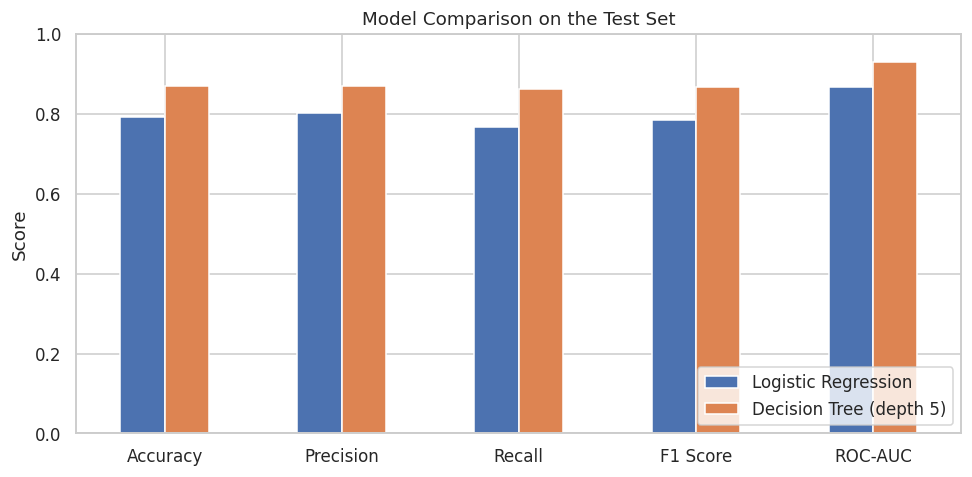

In [14]:
ax = comparison.plot(kind="bar", figsize=(9, 4.5), color=["#4C72B0", "#DD8452"])
ax.set_title("Model Comparison on the Test Set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("screenshots/04_model_comparison.png", bbox_inches="tight")
plt.show()

## 11. Cross-Validation Check

A single train/test split can be lucky. A 5-fold cross-validation on the training set gives a more
honest picture of how stable the score is.

In [15]:
cv_lr = cross_val_score(logreg, X_train, y_train, cv=5, scoring="accuracy")
cv_dt = cross_val_score(tree, X_train, y_train, cv=5, scoring="accuracy")

print("Logistic Regression 5-fold accuracy:", np.round(cv_lr, 4))
print("  mean:", round(cv_lr.mean(), 4), " std:", round(cv_lr.std(), 4))
print()
print("Decision Tree 5-fold accuracy      :", np.round(cv_dt, 4))
print("  mean:", round(cv_dt.mean(), 4), " std:", round(cv_dt.std(), 4))

Logistic Regression 5-fold accuracy: [0.7969 0.7827 0.7842 0.779  0.7945]
  mean: 0.7875  std: 0.007

Decision Tree 5-fold accuracy      : [0.8638 0.8423 0.8274 0.8408 0.8578]
  mean: 0.8464  std: 0.013


## 12. Which Features Matter Most?

For logistic regression the coefficients show direction and strength: a positive coefficient pushes
an order towards "profitable", a negative one pushes it towards "loss".

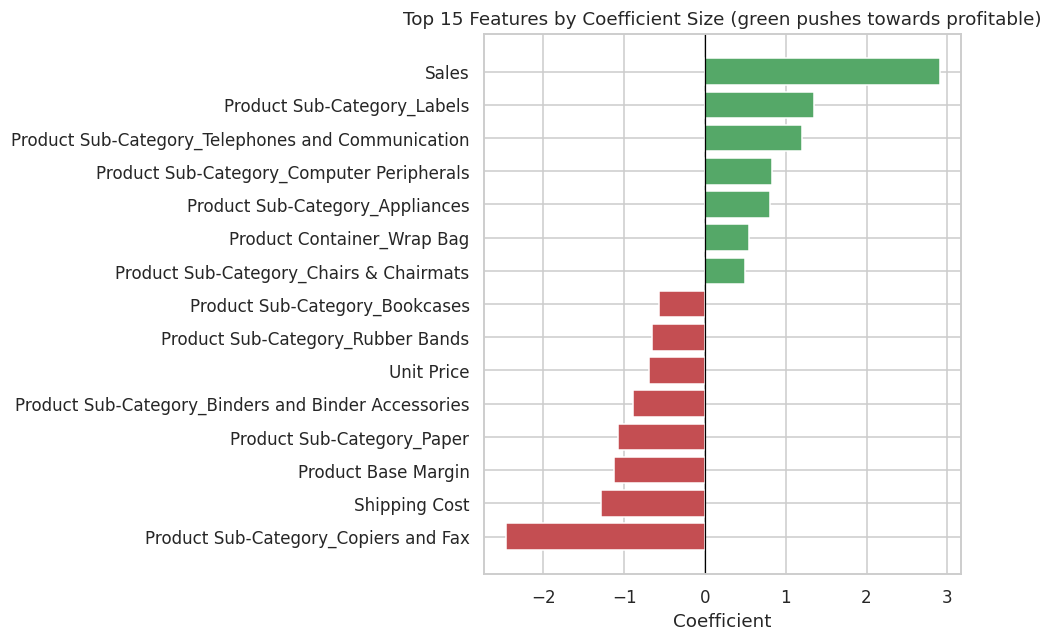

                                                 Feature  Coefficient  Absolute
                                              num__Sales        2.906     2.906
               cat__Product Sub-Category_Copiers and Fax       -2.467     2.467
                        cat__Product Sub-Category_Labels        1.354     1.354
                                      num__Shipping Cost       -1.282     1.282
  cat__Product Sub-Category_Telephones and Communication        1.197     1.197
                                num__Product Base Margin       -1.122     1.122
                         cat__Product Sub-Category_Paper       -1.079     1.079
cat__Product Sub-Category_Binders and Binder Accessories       -0.896     0.896
          cat__Product Sub-Category_Computer Peripherals        0.827     0.827
                    cat__Product Sub-Category_Appliances        0.802     0.802


In [16]:
feature_names = logreg.named_steps["preprocess"].get_feature_names_out()
coefs = logreg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefs})
coef_df["Absolute"] = coef_df["Coefficient"].abs()
top = coef_df.sort_values("Absolute", ascending=False).head(15).sort_values("Coefficient")

plt.figure(figsize=(9, 6))
colors = ["#C44E52" if v < 0 else "#55A868" for v in top["Coefficient"]]
plt.barh(top["Feature"].str.replace("num__", "").str.replace("cat__", ""),
         top["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Features by Coefficient Size (green pushes towards profitable)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.savefig("screenshots/05_feature_importance.png", bbox_inches="tight")
plt.show()

print(coef_df.sort_values("Absolute", ascending=False).head(10).round(3).to_string(index=False))

## 13. Test the Model on a New, Unseen Order

In [17]:
new_orders = pd.DataFrame([
    {   # a small, cheap, low-discount office supplies order
        "Order Quantity": 12, "Sales": 320.50, "Discount": 0.01, "Unit Price": 26.70,
        "Shipping Cost": 4.20, "Product Base Margin": 0.55, "Shipping Delay": 2,
        "Order Priority": "High", "Ship Mode": "Regular Air", "Region": "West",
        "Customer Segment": "Corporate", "Product Category": "Office Supplies",
        "Product Sub-Category": "Pens & Art Supplies", "Product Container": "Small Box"
    },
    {   # a big, heavily discounted furniture order shipped by truck
        "Order Quantity": 45, "Sales": 8900.00, "Discount": 0.10, "Unit Price": 195.00,
        "Shipping Cost": 65.00, "Product Base Margin": 0.60, "Shipping Delay": 8,
        "Order Priority": "Low", "Ship Mode": "Delivery Truck", "Region": "Ontario",
        "Customer Segment": "Consumer", "Product Category": "Furniture",
        "Product Sub-Category": "Tables", "Product Container": "Jumbo Drum"
    }
])

preds = logreg.predict(new_orders)
probs = logreg.predict_proba(new_orders)[:, 1]

for i, (p, pr) in enumerate(zip(preds, probs), start=1):
    label = "PROFITABLE" if p == 1 else "NOT PROFITABLE"
    print(f"Order {i}: {label}  (probability of profit = {pr:.2%})")

Order 1: NOT PROFITABLE  (probability of profit = 26.33%)
Order 2: PROFITABLE  (probability of profit = 88.36%)


## 14. Results Summary, Limitations and Next Steps

### Results
Both models comfortably beat the 50.8% majority-class baseline.

| Metric | Logistic Regression | Decision Tree (depth 5) |
|---|---|---|
| Accuracy | 0.7929 | 0.8685 |
| Precision | 0.8028 | 0.8704 |
| Recall | 0.7678 | 0.8609 |
| F1 Score | 0.7849 | 0.8657 |
| ROC-AUC | 0.8657 | 0.9296 |

The **Decision Tree clearly outperforms the linear baseline** on every metric, which says the
relationship between the features and profitability is not linear. The 5-fold cross-validation
scores (0.7875 and 0.8464 mean accuracy, standard deviation under 0.02) sit close to the
single-split scores, so the result is stable and not a fluke of one lucky split.

The coefficient chart shows what the linear model is keying on. **Sales value is the strongest
push towards profitable**, while **shipping cost and product base margin push towards a loss**.
Beyond that, a lot of the signal is carried by `Product Sub-Category`, which lines up with the
Task 1 finding that profitability is very uneven across sub-categories.

### Limitations
1. **No cost data.** The dataset has no cost of goods sold, so the model can only infer
   profitability from price, discount and shipping. That is a hard ceiling on how accurate it can
   ever get.
2. **Row-level, not order-level.** Each row is a product line, and lines from the same order share
   a customer and a date. The random split can put two lines of the same order on opposite sides of
   the train/test boundary, which is a mild form of leakage.
3. **Random split ignores time.** Real forecasting would train on earlier years and test on later
   ones. This split shuffles all four years together.
4. **No hyperparameter tuning.** Default settings throughout, apart from capping the tree depth.
   This is deliberate for a baseline, but it means neither model is at its best.
5. **The decision threshold is fixed at 0.5.** The business cost of approving a losing order is
   probably not the same as the cost of rejecting a good one, so the threshold should really be
   tuned to that cost.
6. **Linear model on a non-linear problem.** Logistic regression can only draw a straight boundary,
   which is why even a shallow tree competes with it.

### Key Lessons and Improvements for the Next Iteration
- Group the split by `Order ID` (`GroupShuffleSplit`) so no order is spread across train and test.
- Try a time-based split, training on 2009 to 2011 and testing on 2012, which matches how the model
  would actually be used.
- Add engineered features such as revenue per unit, shipping cost as a share of sales, and order
  month, which are likely stronger signals than the raw columns.
- Tune the threshold against a real cost matrix instead of leaving it at 0.5.
- Once the baseline is solid, move to an ensemble such as Random Forest or Gradient Boosting and
  compare it fairly against these numbers.
- Log every experiment's metrics in one table so improvements are measurable rather than assumed.